### Анализ данных аптеки

In [250]:
import pandas as pd

In [2]:
pd.DataFrame([[1,5,6,3], [1,5,6,3]], index=['station_1', 'station_2'], columns=['wind', 'solar', 'pressure', 'speed'])

,wind,solar,pressure,speed
station_1,1,5,6,3
station_2,1,5,6,3


**Загружаем и обрабатываем датафрейм**

In [251]:
df = pd.read_csv('data/data.csv', encoding='1251')

In [17]:
df.tail(3)

,DR_Dat,DR_Tim,DR_NChk,DR_NDoc,DR_Apt,DR_Kkm,DR_TDoc,DR_TPay,DR_CDrugs,DR_NDrugs,DR_Suppl,DR_Prod,DR_Kol,DR_CZak,DR_CRoz,DR_SDisc,DR_CDisc,DR_BCDisc,DR_TabEmpl,DR_VZak,DR_Pos
4459,2022-08-12,21:43:48,5692,18002542,18,9907,Розничная реализация,18,260990,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,Авеста,Северная Звезда,1.00,297.74,396.00,0.00,NaN,NaN,48,1,1.00
4460,2022-08-12,21:44:46,5693,18002542,18,9907,Розничная реализация,18,41512,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,Катрен г.Химки,Кадила Фармасьютикалз Лтд ( CADILA ),1.00,322.06,419.00,0.00,NaN,NaN,48,1,1.00
4461,2022-08-12,21:46:08,5694,18002542,18,9907,Розничная реализация,15,25673,БЕЛЬВЕДЕР ЛАК П/ОБГРЫЗАНИЯ НОГТЕЙ 8МЛ. [BELWEDER],Катрен г.Химки,BELWEDER NORD SIA,1.00,238.62,346.00,34.00,9.00,200010027618.00,48,1,1.00


In [252]:
pd.set_option('display.max_columns', 40)

In [253]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
pd.describe_option()

In [11]:
pd.get_option('display.max_columns')

20

In [14]:
df.dtypes

DR_Dat         object
DR_Tim         object
DR_NChk         int64
DR_NDoc         int64
DR_Apt          int64
DR_Kkm          int64
DR_TDoc        object
DR_TPay         int64
DR_CDrugs       int64
DR_NDrugs      object
DR_Suppl       object
DR_Prod        object
DR_Kol        float64
DR_CZak       float64
DR_CRoz       float64
DR_SDisc      float64
DR_CDisc      float64
DR_BCDisc     float64
DR_TabEmpl      int64
DR_VZak         int64
DR_Pos        float64
dtype: object

In [18]:
df.shape

(4462, 21)

In [19]:
df.size

93702

In [20]:
4462*21

93702

In [21]:
df.index

RangeIndex(start=0, stop=4462, step=1)

In [22]:
pd.DataFrame([[1,5,6,3], [1,5,6,3]], index=['station_1', 'station_2'], columns=['wind', 'solar', 'pressure', 'speed']).index

Index(['station_1', 'station_2'], dtype='object')

In [23]:
df.columns

Index(['DR_Dat', 'DR_Tim', 'DR_NChk', 'DR_NDoc', 'DR_Apt', 'DR_Kkm', 'DR_TDoc',
       'DR_TPay', 'DR_CDrugs', 'DR_NDrugs', 'DR_Suppl', 'DR_Prod', 'DR_Kol',
       'DR_CZak', 'DR_CRoz', 'DR_SDisc', 'DR_CDisc', 'DR_BCDisc', 'DR_TabEmpl',
       'DR_VZak', 'DR_Pos'],
      dtype='object')

In [254]:
our_cols = ['DR_Dat', 'DR_Tim', 'DR_NChk', 'DR_NDoc', 'DR_Apt', 'DR_NDrugs', 'DR_Kol',
       'DR_CZak', 'DR_CRoz', 'DR_SDisc', 'DR_TPay', 'DR_CDrugs', 'DR_Suppl', 'DR_CDisc', 'DR_BCDisc', 'DR_TabEmpl', 'DR_VZak', 'DR_Pos']

In [255]:
df = df[our_cols]

In [30]:
df.head()

,DR_Dat,DR_Tim,DR_NChk,DR_NDoc,DR_Apt,DR_NDrugs,DR_Kol,DR_CZak,DR_CRoz,DR_SDisc,DR_TPay,DR_CDrugs,DR_Suppl,DR_CDisc,DR_BCDisc,DR_TabEmpl,DR_VZak,DR_Pos
0,2022-08-11,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925.00,200000000492.00,205,1,1.00
1,2022-08-11,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9.00,200010010204.00,205,1,1.00
2,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9.00,200010010204.00,205,1,2.00
3,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9.00,200010010204.00,205,1,3.00
4,2022-08-11,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925.00,200000000492.00,205,1,1.00


In [31]:
df.shape

(4462, 18)

In [256]:
df.columns = ['dt', 'c_time', 'nchk', 'ndoc', 'apt', 'drug', 'kol',
       'zak', 'roz', 'disc', 'pay_type', 'drug_id', 'suppl', 'disc_id', 'disc_barcode', 'empl', 'vzak', 'pos']

In [33]:
df

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,2022-08-11,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925.00,200000000492.00,205,1,1.00
1,2022-08-11,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9.00,200010010204.00,205,1,1.00
2,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9.00,200010010204.00,205,1,2.00
3,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9.00,200010010204.00,205,1,3.00
4,2022-08-11,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925.00,200000000492.00,205,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,2022-08-12,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,NaN,NaN,48,1,1.00
4458,2022-08-12,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,NaN,NaN,48,1,1.00
4459,2022-08-12,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,NaN,NaN,48,1,1.00
4460,2022-08-12,21:44:46,5693,18002542,18,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,1.00,322.06,419.00,0.00,18,41512,Катрен г.Химки,NaN,NaN,48,1,1.00


In [34]:
df.dtypes

dt               object
c_time           object
nchk              int64
ndoc              int64
apt               int64
drug             object
kol             float64
zak             float64
roz             float64
disc            float64
pay_type          int64
drug_id           int64
suppl            object
disc_id         float64
disc_barcode    float64
empl              int64
vzak              int64
pos             float64
dtype: object

In [36]:
df['disc_barcode'].dtype

dtype('float64')

In [257]:
df['disc_barcode'] = df['disc_barcode'].astype('str').replace('\.0', '', regex=True)

In [51]:
df.dtypes

dt               object
c_time           object
nchk              int64
ndoc              int64
apt               int64
drug             object
kol             float64
zak             float64
roz             float64
disc            float64
pay_type          int64
drug_id           int64
suppl            object
disc_id         float64
disc_barcode     object
empl              int64
vzak              int64
pos             float64
dtype: object

In [258]:
df['disc_id'] = df['disc_id'].astype('str').replace('\.0', '', regex=True)

In [55]:
df

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,2022-08-11,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,1,1.00
1,2022-08-11,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9,200010010204,205,1,1.00
2,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9,200010010204,205,1,2.00
3,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9,200010010204,205,1,3.00
4,2022-08-11,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,2022-08-12,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,nan,nan,48,1,1.00
4458,2022-08-12,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,nan,nan,48,1,1.00
4459,2022-08-12,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,nan,nan,48,1,1.00
4460,2022-08-12,21:44:46,5693,18002542,18,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,1.00,322.06,419.00,0.00,18,41512,Катрен г.Химки,nan,nan,48,1,1.00


In [259]:
df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%d.%m.%Y')

In [67]:
pd.to_datetime(df['dt']).dt.day_of_year

C:\Users\User\AppData\Local\Temp\ipykernel_5908\1783154511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dt'] = pd.to_datetime(df['dt']).dt.day_of_year


In [65]:
df.dtypes

dt               object
c_time           object
nchk              int64
ndoc              int64
apt               int64
drug             object
kol             float64
zak             float64
roz             float64
disc            float64
pay_type          int64
drug_id           int64
suppl            object
disc_id          object
disc_barcode     object
empl              int64
vzak              int64
pos             float64
dtype: object

In [11]:
df

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,1,1.00
1,11.08.2022,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9,200010010204,205,1,1.00
2,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9,200010010204,205,1,2.00
3,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9,200010010204,205,1,3.00
4,11.08.2022,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,12.08.2022,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,nan,nan,48,1,1.00
4458,12.08.2022,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,nan,nan,48,1,1.00
4459,12.08.2022,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,nan,nan,48,1,1.00
4460,12.08.2022,21:44:46,5693,18002542,18,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,1.00,322.06,419.00,0.00,18,41512,Катрен г.Химки,nan,nan,48,1,1.00


In [69]:
df2 = pd.read_csv('data/data.csv', encoding='1251')

In [70]:
df['dt'] = pd.to_datetime(df2['DR_Dat']).dt.strftime('%d.%m.%Y')

C:\Users\User\AppData\Local\Temp\ipykernel_5908\854889711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dt'] = pd.to_datetime(df2['DR_Dat']).dt.strftime('%d.%m.%Y')


In [71]:
df.head(1)

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,1,1.00


In [74]:
df['vzak'].unique()

array([1, 2], dtype=int64)

In [260]:
df['vzak'] = df['vzak'].astype('str').replace('1', 'Обычный').replace('2', 'Интернет')

In [78]:
df

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,Обычный,1.00
1,11.08.2022,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9,200010010204,205,Обычный,1.00
2,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9,200010010204,205,Обычный,2.00
3,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9,200010010204,205,Обычный,3.00
4,11.08.2022,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,Обычный,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,12.08.2022,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,nan,nan,48,Обычный,1.00
4458,12.08.2022,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,nan,nan,48,Обычный,1.00
4459,12.08.2022,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,nan,nan,48,Обычный,1.00
4460,12.08.2022,21:44:46,5693,18002542,18,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,1.00,322.06,419.00,0.00,18,41512,Катрен г.Химки,nan,nan,48,Обычный,1.00


In [89]:
df.isna().any()

dt              False
c_time          False
nchk            False
ndoc            False
apt             False
drug            False
kol             False
zak             False
roz             False
disc            False
pay_type        False
drug_id         False
suppl           False
disc_id         False
disc_barcode    False
empl            False
vzak            False
pos             False
dtype: bool

In [90]:
df2.isna().any()

DR_Dat        False
DR_Tim        False
DR_NChk       False
DR_NDoc       False
DR_Apt        False
DR_Kkm        False
DR_TDoc       False
DR_TPay       False
DR_CDrugs     False
DR_NDrugs     False
DR_Suppl      False
DR_Prod       False
DR_Kol        False
DR_CZak       False
DR_CRoz       False
DR_SDisc      False
DR_CDisc       True
DR_BCDisc      True
DR_TabEmpl    False
DR_VZak       False
DR_Pos        False
dtype: bool

In [91]:
df2.fillna(0).isna().any()

DR_Dat        False
DR_Tim        False
DR_NChk       False
DR_NDoc       False
DR_Apt        False
DR_Kkm        False
DR_TDoc       False
DR_TPay       False
DR_CDrugs     False
DR_NDrugs     False
DR_Suppl      False
DR_Prod       False
DR_Kol        False
DR_CZak       False
DR_CRoz       False
DR_SDisc      False
DR_CDisc      False
DR_BCDisc     False
DR_TabEmpl    False
DR_VZak       False
DR_Pos        False
dtype: bool

In [111]:
df3 = df2[df2.isna().values.any(axis=1)]

In [112]:
df3

,DR_Dat,DR_Tim,DR_NChk,DR_NDoc,DR_Apt,DR_Kkm,DR_TDoc,DR_TPay,DR_CDrugs,DR_NDrugs,DR_Suppl,DR_Prod,DR_Kol,DR_CZak,DR_CRoz,DR_SDisc,DR_CDisc,DR_BCDisc,DR_TabEmpl,DR_VZak,DR_Pos
15,2022-08-11,11:00:23,2178,2004598,2,22577,Розничная реализация,18,496504,"НАФТИЗИН 0,1% 15МЛ. НАЗАЛ.КАПЛИ ФЛ./КАП. /ЛЕККО/",Катрен г.Химки,ЛЕККО ФФ ЗАО,1.00,12.94,18.00,0.00,NaN,NaN,205,1,1.00
16,2022-08-11,11:00:23,2178,2004598,2,22577,Розничная реализация,18,496504,"НАФТИЗИН 0,1% 15МЛ. НАЗАЛ.КАПЛИ ФЛ./КАП. /ЛЕККО/",Катрен г.Химки,ЛЕККО ФФ ЗАО,1.00,12.94,18.00,0.00,NaN,NaN,205,1,2.00
20,2022-08-11,11:31:34,2181,2004598,2,22577,Розничная реализация,18,14120,ЛАКТОФИЛЬТРУМ 500МГ. №60 ТАБ.,Пульс,АВВА РУС ОАО,1.00,408.63,560.00,0.00,NaN,NaN,205,1,1.00
21,2022-08-11,11:31:34,2181,2004598,2,22577,Розничная реализация,18,78641,ФЕСТАЛ №40 ДРАЖЕ,ВИТТА КОМПАНИ ООО,SANOFI,1.00,333.74,458.00,0.00,NaN,NaN,205,1,2.00
22,2022-08-11,11:36:05,2182,2004598,2,22577,Розничная реализация,15,18849,ДОКТОР МОМ №20 ПАСТИЛКИ МАЛИНА,Пульс,Юник Фармасьютикал Лабораториз (Отделение Дж.Б...,1.00,141.55,200.00,0.00,NaN,NaN,205,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,2022-08-12,21:39:23,5689,18002542,18,9907,Розничная реализация,18,28488,АЛЬБАДЕНТ ОСВЕЖИТЕЛЬ Д/РТА ЛИМОН 35МЛ. СПРЕЙ,Здравсервис,"ХБО при РАН ""Вита""",1.00,62.34,97.00,0.00,NaN,NaN,48,1,1.00
4457,2022-08-12,21:40:17,5690,18002542,18,9907,Розничная реализация,18,463100,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,Д-р Редди с Лабораторис Лтд / Dr.REDDY's,1.00,47.88,75.00,0.00,NaN,NaN,48,1,1.00
4458,2022-08-12,21:40:59,5691,18002542,18,9907,Розничная реализация,18,112158,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,Протек,ИНАТ-ФАРМА,1.00,59.51,93.00,0.00,NaN,NaN,48,1,1.00
4459,2022-08-12,21:43:48,5692,18002542,18,9907,Розничная реализация,18,260990,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,Авеста,Северная Звезда,1.00,297.74,396.00,0.00,NaN,NaN,48,1,1.00


In [116]:
df3.fillna(0).head(5)[['DR_CDisc']]

,DR_CDisc
15,0.00
16,0.00
20,0.00
21,0.00
22,0.00


In [127]:
df2['DR_CDisc'].interpolate(method='linear')

0      925.00
1        9.00
2        9.00
3        9.00
4      925.00
        ...  
4457     9.00
4458     9.00
4459     9.00
4460     9.00
4461     9.00
Name: DR_CDisc, Length: 4462, dtype: float64

In [128]:
df2.shape

(4462, 21)

In [131]:
df2.dropna(axis=1).shape

(4462, 19)

**Exploratory data analysis - разведочный анализ данных**

In [261]:
import pandas as pd

In [262]:
df

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,Обычный,1.00
1,11.08.2022,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9,200010010204,205,Обычный,1.00
2,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9,200010010204,205,Обычный,2.00
3,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9,200010010204,205,Обычный,3.00
4,11.08.2022,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,Обычный,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,12.08.2022,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,nan,nan,48,Обычный,1.00
4458,12.08.2022,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,nan,nan,48,Обычный,1.00
4459,12.08.2022,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,nan,nan,48,Обычный,1.00
4460,12.08.2022,21:44:46,5693,18002542,18,ТОБРАЗОН 5МЛ. ГЛ.КАПЛИ ФЛ.,1.00,322.06,419.00,0.00,18,41512,Катрен г.Химки,nan,nan,48,Обычный,1.00


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dt            4462 non-null   object 
 1   c_time        4462 non-null   object 
 2   nchk          4462 non-null   int64  
 3   ndoc          4462 non-null   int64  
 4   apt           4462 non-null   int64  
 5   drug          4462 non-null   object 
 6   kol           4462 non-null   float64
 7   zak           4462 non-null   float64
 8   roz           4462 non-null   float64
 9   disc          4462 non-null   float64
 10  pay_type      4462 non-null   int64  
 11  drug_id       4462 non-null   int64  
 12  suppl         4462 non-null   object 
 13  disc_id       4462 non-null   object 
 14  disc_barcode  4462 non-null   object 
 15  empl          4462 non-null   int64  
 16  vzak          4462 non-null   object 
 17  pos           4462 non-null   float64
dtypes: float64(5), int64(6), obj

In [264]:
df.describe()

,nchk,ndoc,apt,kol,zak,roz,disc,pay_type,drug_id,empl,pos
count,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00
mean,4903.14,10842995.33,10.84,1.03,241.64,306.05,10.56,16.90,259227.09,91.74,2.68
std,1839.70,6107181.40,6.11,0.54,454.56,532.17,31.37,1.45,299073.90,108.08,2.75
min,1698.00,2004595.00,2.00,0.01,0.01,0.01,0.00,15.00,3.00,25.00,1.00
25%,4187.00,6003620.00,6.00,1.00,36.64,52.00,0.00,15.00,29060.00,37.00,1.00
50%,4877.50,11007039.00,11.00,1.00,103.78,137.00,0.00,18.00,187304.00,53.00,2.00
75%,5472.75,18002536.00,18.00,1.00,299.06,391.75,7.00,18.00,377589.00,123.00,3.00
max,8490.00,18002543.00,18.00,20.00,11851.13,12345.00,650.00,18.00,1504498.00,605.00,24.00


In [265]:
df['pay_type'].value_counts()

18    2820
15    1642
Name: pay_type, dtype: int64

In [267]:
df.apt.value_counts()

18    1207
2      979
11     870
6      511
13     322
17     243
15     177
7      153
Name: apt, dtype: int64

In [268]:
df.apt.value_counts(normalize=True)

18   0.27
2    0.22
11   0.19
6    0.11
13   0.07
17   0.05
15   0.04
7    0.03
Name: apt, dtype: float64

In [271]:
df.pos.unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 23., 24., 22.])

In [273]:
df.pos.value_counts()

1.00     2019
2.00      971
3.00      528
4.00      301
5.00      178
6.00      117
7.00       76
8.00       56
9.00       42
10.00      37
11.00      30
12.00      25
13.00      21
14.00      17
15.00      14
16.00       9
17.00       7
18.00       4
19.00       3
20.00       2
21.00       2
23.00       1
24.00       1
22.00       1
Name: pos, dtype: int64

<AxesSubplot:>

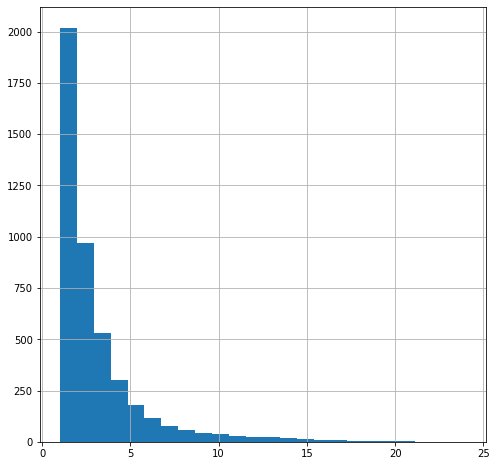

In [276]:
df.pos.hist(bins=24)

In [281]:
import seaborn as sns
import matplotlib.pyplot as plt

<AxesSubplot:>

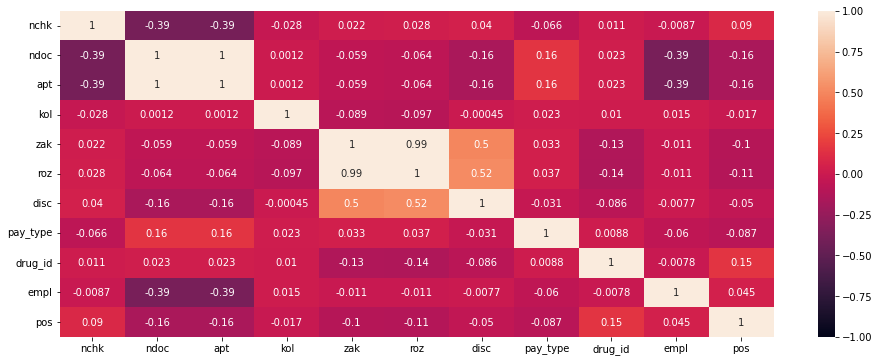

In [282]:
plt.figure(figsize=(16, 6))
sns.heatmap(df.corr(), vmax=1, vmin=-1, annot=True)

In [284]:
plt.rcParams['figure.figsize'] = (16, 6)

<AxesSubplot:>

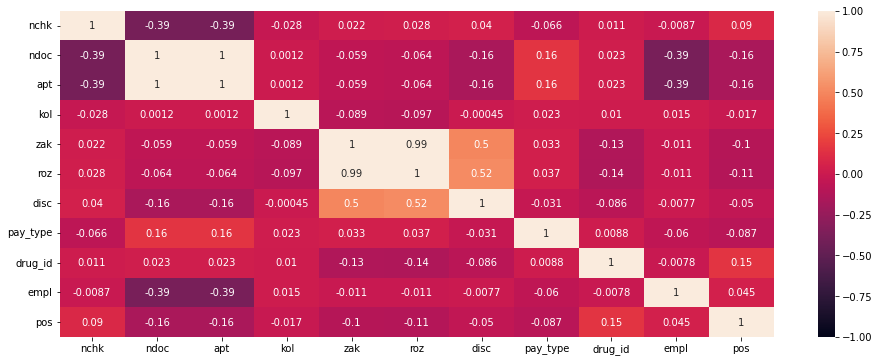

In [285]:
sns.heatmap(df.corr(), vmax=1, vmin=-1, annot=True)

In [289]:
df['hour'] = pd.to_datetime(df.c_time).dt.hour

In [290]:
df['hour']

0       10
1       10
2       10
3       10
4       10
        ..
4457    21
4458    21
4459    21
4460    21
4461    21
Name: hour, Length: 4462, dtype: int64

In [291]:
df.head()

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos,hour
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,Обычный,1.00,10
1,11.08.2022,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9,200010010204,205,Обычный,1.00,10
2,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9,200010010204,205,Обычный,2.00,10
3,11.08.2022,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9,200010010204,205,Обычный,3.00,10
4,11.08.2022,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,Обычный,1.00,10


In [296]:
gr = df.groupby(['hour'])['kol'].agg(sum)

In [298]:
gr

hour
8     20.10
9    236.50
10   361.65
11   326.55
12   311.59
13   422.80
14   358.30
15   432.97
16   375.88
17   375.45
18   457.50
19   419.29
20   388.57
21    97.71
22     1.00
Name: kol, dtype: float64

c:\Users\User\Desktop\Pandas\venv\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='kol'>

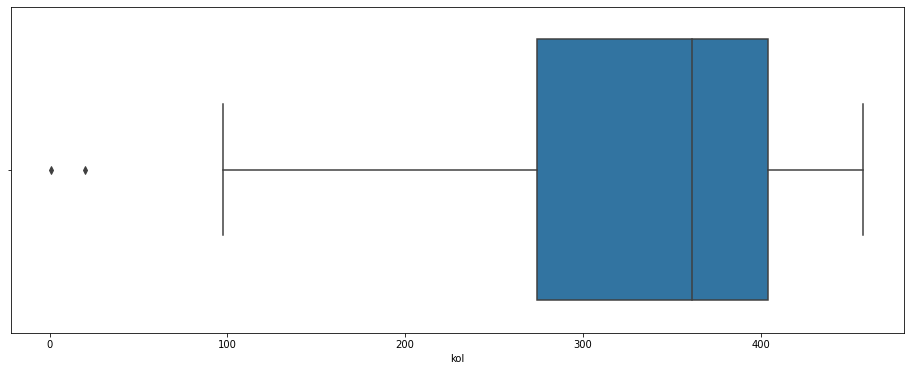

In [297]:
sns.boxplot(gr)

In [300]:
a = df.groupby(['dt', 'nchk'])['kol', 'roz', 'zak'].agg({
    'kol': sum, 
    'roz': ['sum', 'max'],
    'zak': sum
})

C:\Users\User\AppData\Local\Temp\ipykernel_12916\4135302964.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  a = df.groupby(['dt', 'nchk'])['kol', 'roz', 'zak'].agg({


In [302]:
a

kol     roz           zak
                  sum     sum    max    sum
dt         nchk                            
11.08.2022 1698  1.00  463.00 463.00 342.30
           1699  1.00  720.00 720.00 545.27
           1700  1.00   60.00  60.00  36.68
           1701  4.00  955.00 443.00 756.12
           1702  1.00   94.00  94.00  76.55
...               ...     ...    ...    ...
12.08.2022 8486  1.00  460.00 460.00 302.07
           8487  1.00  476.00 476.00 396.66
           8488  1.00  220.00 220.00 187.84
           8489 18.00 1089.00 180.00 778.61
           8490  3.00  869.00 775.00 626.13

[1941 rows x 4 columns]

In [305]:
a.reset_index()

dt  nchk   kol     roz           zak
                         sum     sum    max    sum
0     11.08.2022  1698  1.00  463.00 463.00 342.30
1     11.08.2022  1699  1.00  720.00 720.00 545.27
2     11.08.2022  1700  1.00   60.00  60.00  36.68
3     11.08.2022  1701  4.00  955.00 443.00 756.12
4     11.08.2022  1702  1.00   94.00  94.00  76.55
...          ...   ...   ...     ...    ...    ...
1936  12.08.2022  8486  1.00  460.00 460.00 302.07
1937  12.08.2022  8487  1.00  476.00 476.00 396.66
1938  12.08.2022  8488  1.00  220.00 220.00 187.84
1939  12.08.2022  8489 18.00 1089.00 180.00 778.61
1940  12.08.2022  8490  3.00  869.00 775.00 626.13

[1941 rows x 6 columns]

In [307]:
a = df.groupby(['dt', 'empl'])['zak', 'roz'].agg(sum)

C:\Users\User\AppData\Local\Temp\ipykernel_12916\760816077.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  a = df.groupby(['dt', 'empl'])['zak', 'roz'].agg(sum)


In [308]:
a['revenue'] = a['roz'] - a['zak']

In [309]:
a

zak       roz  revenue
dt         empl                            
11.08.2022 25   72004.24  93030.00 21025.76
           30   90350.41 111916.97 21566.56
           36   62425.32  77368.03 14942.71
           47   68458.33  86626.01 18167.68
           50   72304.41  90830.01 18525.60
           53   37727.08  48746.00 11018.92
           54   52880.81  67517.08 14636.27
           123  88926.21 116678.03 27751.82
           205  49904.42  59471.00  9566.58
           605  28699.65  36954.01  8254.36
12.08.2022 37   92688.93 118091.37 25402.44
           48   72773.60  93032.02 20258.42
           54   65852.52  83229.05 17376.53
           110  89126.47 113275.05 24148.58
           123  99298.80 124231.66 24932.86
           205  34772.17  44595.01  9822.84

In [311]:
df.groupby(['dt', 'empl'])['zak', 'roz', 'kol'].apply(lambda x: sum(x['kol']*(x['roz'] - x['zak'])))

C:\Users\User\AppData\Local\Temp\ipykernel_12916\3454623298.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(['dt', 'empl'])['zak', 'roz', 'kol'].apply(lambda x: sum(x['kol']*(x['roz'] - x['zak'])))


dt          empl
11.08.2022  25     20642.29
            30     20328.67
            36     14090.04
            47     16983.79
            50     17384.41
            53     10056.40
            54     13981.47
            123    23756.34
            205     9724.19
            605     8341.71
12.08.2022  37     22613.80
            48     19244.82
            54     16801.83
            110    22711.32
            123    23167.41
            205     8873.30
dtype: float64

In [312]:
df.columns

Index(['dt', 'c_time', 'nchk', 'ndoc', 'apt', 'drug', 'kol', 'zak', 'roz',
       'disc', 'pay_type', 'drug_id', 'suppl', 'disc_id', 'disc_barcode',
       'empl', 'vzak', 'pos', 'hour'],
      dtype='object')

In [313]:
import numpy as np

In [314]:
df.groupby(['dt', 'drug'])['roz', 'kol'].agg({
    'roz': np.mean, 
    'kol': sum
})

C:\Users\User\AppData\Local\Temp\ipykernel_12916\1098215732.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(['dt', 'drug'])['roz', 'kol'].agg({


roz  kol
dt         drug                                                           
11.08.2022 911-ГЕЛЬ-БАЛЬЗАМ Д/СУСТАВОВ ОКОПНИК 100МЛ. ТУБА     111.00 1.00
           911-ГЕЛЬ-БАЛЬЗАМ Д/СУСТАВОВ САБЕЛЬНИК 100МЛ.        104.00 1.00
           L-ТИРОКСИН 150МКГ. №100 ТАБ. /БЕРЛИН ХЕМИ/          170.00 1.00
           L-ТИРОКСИН 50МКГ. №50 ТАБ. /БЕРЛИН ХЕМИ/             93.00 1.00
           ZD ТЕЙМУРОВА СПРЕЙ Д/НОГ П/ПОТА И ЗАПАХА 150МЛ....   96.00 1.00
...                                                               ...  ...
12.08.2022 ЭУФИЛЛИН 150МГ. №30 ТАБ. /ФАРМСТАНДАРТ/              31.00 2.00
           ЮНИЭНЗИМ С МПС №20 ТАБ. П/О                         141.00 1.00
           Я ЗАБОЧУСЬ О ЗДОРОВЬЕ ТРАВЯН.КОФЕ КОФЕЙНЫЙ НАПИ...  145.00 1.00
           ЯНТАРНАЯ К-ТА ФОРП 100МГ. №10 ТАБ.                   14.00 2.00
           ЯРИНА №21 ТАБ. П/П/О                               1292.00 1.00

[2304 rows x 2 columns]

In [320]:
df['rroz'] = df.roz.apply(lambda x: round(x, -2))

In [323]:
a = df.groupby(['dt', 'rroz'])['kol'].agg(sum).reset_index()

In [388]:
a = a[a.loc[:, 'rroz'] < 2000]

c:\Users\User\Desktop\Pandas\venv\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='rroz', ylabel='kol'>

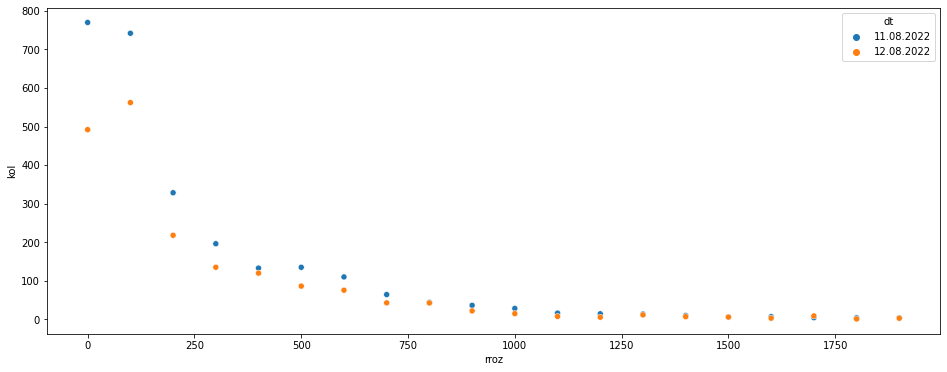

In [389]:
sns.scatterplot(a.rroz, a.kol, hue=a.dt)

c:\Users\User\Desktop\Pandas\venv\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


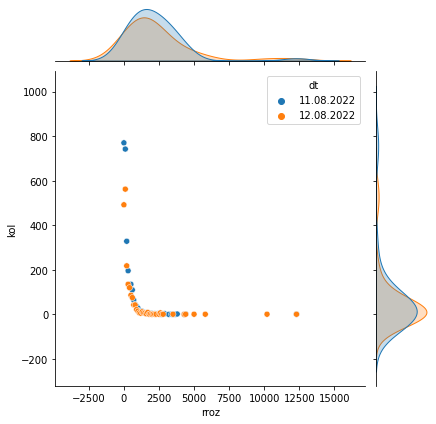

In [327]:
sns.jointplot(a.rroz, a.kol, hue=a.dt)

In [341]:
b = df.groupby(['dt', 'apt', 'empl', 'pay_type'])['kol'].agg(sum).reset_index()

In [342]:
b

,dt,apt,empl,pay_type,kol
0,11.08.2022,2,123,15,151.05
1,11.08.2022,2,123,18,164.13
2,11.08.2022,2,205,15,65.11
3,11.08.2022,2,205,18,66.00
4,11.08.2022,6,25,15,95.00
5,11.08.2022,6,25,18,142.53
6,11.08.2022,7,605,15,67.04
7,11.08.2022,7,605,18,101.85
8,11.08.2022,11,30,15,179.00
9,11.08.2022,11,30,18,310.48


In [343]:
b.pivot_table(values='kol', index=['dt', 'apt', 'empl'], columns=['pay_type'])

pay_type                15     18
dt         apt empl              
11.08.2022 2   123  151.05 164.13
               205   65.11  66.00
           6   25    95.00 142.53
           7   605   67.04 101.85
           11  30   179.00 310.48
           13  50   180.40 151.78
           15  53    51.98 142.10
           17  36    54.73 186.94
           18  47    89.04 236.24
               54    65.10 198.77
12.08.2022 2   123  210.50 152.72
               205   88.41  80.19
           6   37    72.92 207.89
           11  110   91.67 363.08
           18  48   134.79 222.65
               54    64.10 197.65

In [351]:
c = df.pivot_table(values='roz', index=['dt', 'apt', 'empl'], columns=['pay_type'], aggfunc=sum)

In [354]:
c = c.reset_index()

In [357]:
pd.melt(c, id_vars=['dt', 'apt', 'empl'], value_vars=[15, 18], var_name='p_type')

,dt,apt,empl,p_type,value
0,11.08.2022,2,123,15,55981.01
1,11.08.2022,2,205,15,27403.00
2,11.08.2022,6,25,15,27402.00
3,11.08.2022,7,605,15,17618.00
4,11.08.2022,11,30,15,38692.32
5,11.08.2022,13,50,15,44746.00
6,11.08.2022,15,53,15,20155.00
7,11.08.2022,17,36,15,20890.00
8,11.08.2022,18,47,15,25685.01
9,11.08.2022,18,54,15,12118.00


In [358]:
df[['zak', 'roz']]

,zak,roz
0,41.08,51.00
1,18.61,31.00
2,132.69,209.00
3,133.65,210.00
4,709.95,787.00
...,...,...
4457,47.88,75.00
4458,59.51,93.00
4459,297.74,396.00
4460,322.06,419.00


In [359]:
df.zak

0       41.08
1       18.61
2      132.69
3      133.65
4      709.95
        ...  
4457    47.88
4458    59.51
4459   297.74
4460   322.06
4461   238.62
Name: zak, Length: 4462, dtype: float64

In [363]:
df.iloc[2:5, 1:5]

,c_time,nchk,ndoc,apt
2,10:27:46,2174,2004598,2
3,10:27:46,2174,2004598,2
4,10:33:56,2175,2004598,2


In [368]:
df.loc[2, 'zak']

132.69

In [367]:
df.at[2, "zak"]

132.69

In [369]:
df.iat[2, 5]

'СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ 125МЛ.'

In [377]:
df[(df['kol'] > 5) & (df['roz'] > 50)]

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos,hour,rroz
1151,11.08.2022,13:10:36,5115,6003620,6,СФМ СИСТЕМА Д/ПЕРЕЛИВ. ИНФУЗ. Р-РОВ №1 ПЛАСТ.И...,10.00,29.80,52.00,62.00,15,422260,Пульс,35,200000000022,25,Обычный,9.00,13,100.00


In [382]:
df[~df.loc[:, 'pay_type'].isin([15, 20])]

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos,hour,rroz
0,11.08.2022,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925,200000000492,205,Обычный,1.00,10,100.00
4,11.08.2022,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925,200000000492,205,Обычный,1.00,10,800.00
5,11.08.2022,10:40:38,2176,2004598,2,БИСОПРОЛОЛ 5МГ. №60 ТАБ. П/П/О /ВЕРТЕКС/,1.00,152.90,182.00,9.00,18,187304,Пульс,9,200010001947,205,Обычный,1.00,10,200.00
6,11.08.2022,10:40:38,2176,2004598,2,ТРИХОПОЛ 250МГ. №20 ТАБ. /ПОЛЬФАРМА/,1.00,67.94,85.00,4.00,18,1261,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,9,200010001947,205,Обычный,2.00,10,100.00
7,11.08.2022,10:52:52,2177,2004598,2,НОРВАСК 5МГ. №30 ТАБ. /ПФАЙЗЕР/АПДЖОН/,1.00,157.76,189.00,9.00,18,2566,Катрен г.Химки,9,200010013331,205,Обычный,3.00,10,200.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,12.08.2022,21:39:23,5689,18002542,18,АЛЬБАДЕНТ ОСВЕЖИТЕЛЬ Д/РТА ЛИМОН 35МЛ. СПРЕЙ,1.00,62.34,97.00,0.00,18,28488,Здравсервис,nan,nan,48,Обычный,1.00,21,100.00
4457,12.08.2022,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,nan,nan,48,Обычный,1.00,21,100.00
4458,12.08.2022,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,nan,nan,48,Обычный,1.00,21,100.00
4459,12.08.2022,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,nan,nan,48,Обычный,1.00,21,400.00
